In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_to_file = r'C:\Users\Yana\Desktop\2_bookings.csv'
bookings = pd.read_csv(path_to_file,encoding = 'Windows-1251', sep=';')

In [55]:
print("Table size: ", bookings.shape)

Table size:  (119390, 21)


In [60]:
print(bookings.dtypes)

hotel                            str
is_canceled                    int64
lead_time                      int64
arrival_full_date                str
arrival_date_year              int64
arrival_date_month               str
arrival_date_week_number       int64
arrival_date_day_of_month      int64
stays_in_weekend_nights        int64
stays_in_week_nights           int64
stays_total_nights             int64
adults                         int64
children                     float64
babies                         int64
meal                             str
country                          str
reserved_room_type               str
assigned_room_type               str
customer_type                    str
reservation_status               str
reservation_status_date          str
dtype: object


In [62]:
bookings.head(7)

,hotel,is_canceled,lead_time,arrival_full_date,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,adults,children,babies,meal,country,reserved_room_type,assigned_room_type,customer_type,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,C,Transient,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015-07-01,2015,July,27,1,0,2,...,2,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015-07-01,2015,July,27,1,0,2,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015-07-01,2015,July,27,1,0,2,...,2,0.0,0,FB,PRT,C,C,Transient,Check-Out,2015-07-03


In [58]:
bookings.columns = [col.lower() for col in bookings.columns]
bookings.columns = bookings.columns.str.replace(' ', '_')

duplicates = bookings.duplicated().sum()
print("Number of duplicate rows: ",  duplicates)
if duplicates > 0:
    bookings = bookings.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows:  36235
Duplicates removed.


In [31]:
bookings.isnull().sum()

hotel                          0
is_canceled                    0
lead_time                      0
arrival_full_date              0
arrival_date_year              0
arrival_date_month             0
arrival_date_week_number       0
arrival_date_day_of_month      0
stays_in_weekend_nights        0
stays_in_week_nights           0
stays_total_nights             0
adults                         0
children                       4
babies                         0
meal                           0
country                      433
reserved_room_type             0
assigned_room_type             0
customer_type                  0
reservation_status             0
reservation_status_date        0
dtype: int64

In [32]:
bookings['children'] = bookings['children'].fillna(0).astype(int)
bookings['country'] = bookings['country'].fillna('Unknown')

In [33]:
successful = bookings[bookings['is_canceled']==0]
top_countries = successful['country'].value_counts().head(5)
print("Top 5 countries by successful bookings: ")
print(top_countries)

Top 5 countries by successful bookings: 
country
PRT    16138
GBR     7803
FRA     6808
ESP     5076
DEU     4130
Name: count, dtype: int64


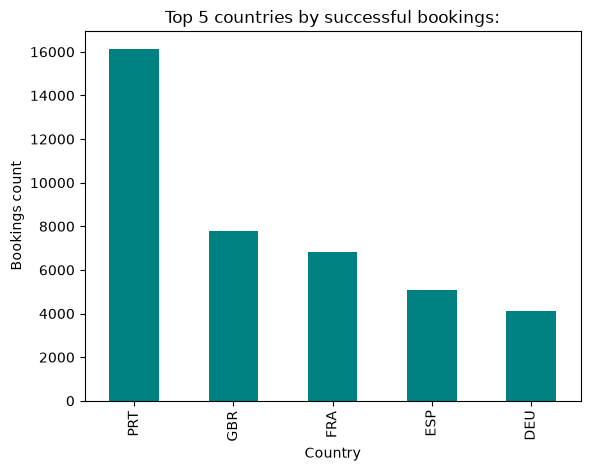

In [34]:
top_countries.plot(kind='bar', color='teal')
plt.title('Top 5 countries by successful bookings:')
plt.xlabel('Country')
plt.ylabel('Bookings count')
plt.show()

In [40]:
avg_nights = bookings.groupby('hotel')['stays_total_nights'].mean().round(2)

print("\nAverage number of nights by hotel type:")
print(avg_nights)

# Let's also look at the median (more robust to outliers)
print("\nMedian number of nights:")
print(bookings.groupby('hotel')['stays_total_nights'].median())


Average number of nights by hotel type:
hotel
City Hotel      3.17
Resort Hotel    4.44
Name: stays_total_nights, dtype: float64

Median number of nights:
hotel
City Hotel      3.0
Resort Hotel    4.0
Name: stays_total_nights, dtype: float64


In [64]:
changed_room = bookings[bookings['reserved_room_type'] != bookings['assigned_room_type']]
print("Number of observations with a change in room type: ", len(changed_room))
print("Replacement rate: ", round(len(changed_room) / len(bookings) * 100, 2))


Number of observations with a change in room type:  12323
Replacement rate:  14.82


In [65]:
print("Replacement based on hotel type:")
print(changed_room['hotel'].value_counts())

Replacement based on hotel type:
hotel
Resort Hotel    6428
City Hotel      5895
Name: count, dtype: int64


In [68]:
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
bookings['arrival_date_month_num'] = bookings['arrival_date_month'].map(month_map)

bookings_2016 = bookings[bookings['arrival_date_year'] == 2016]
top_month_2016 = bookings_2016['arrival_date_month_num'].value_counts().idxmax()
print("The most popular month in 2016: ", top_month_2016)

bookings_2017 = bookings[bookings['arrival_date_year'] == 2017]
top_month_2017 = bookings_2017['arrival_date_month_num'].value_counts().idxmax()
print("The most popular month in 2017: ", top_month_2017)

The most popular month in 2016:  8
The most popular month in 2017:  7


In [71]:
city_hotel = bookings[bookings['hotel'] == 'City Hotel']
cancellations_city = city_hotel[city_hotel['is_canceled'] == 1].groupby(
    ['arrival_date_year', 'arrival_date_month_num']).size()
print("Month with the peak number of cancellations for City Hotel, by year:")
print(cancellations_city.groupby('arrival_date_year').idxmax())

Month with the peak number of cancellations for City Hotel, by year:
arrival_date_year
2015    (2015, 9)
2016    (2016, 8)
2017    (2017, 5)
dtype: object


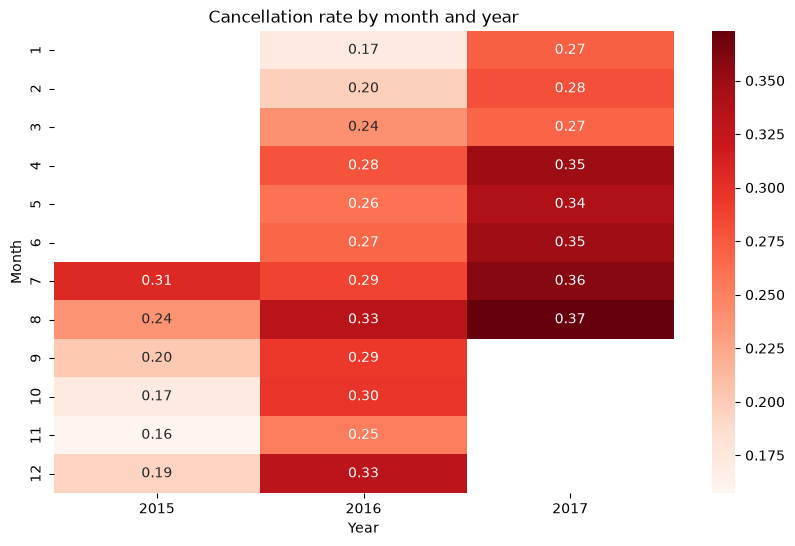

In [70]:
# Seasonality visualization (heatmap)
pivot = bookings.pivot_table(index='arrival_date_month_num', 
                       columns='arrival_date_year', 
                       values='is_canceled', 
                       aggfunc='mean')  # cancellation rate
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.2f')
plt.title('Cancellation rate by month and year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

In [77]:
# Numerical characteristics of guests
print("Average values:")
print("Adults: ",bookings['adults'].mean().round(2))
print("Children: ",bookings['children'].mean().round(2))
print("Babies: ",bookings['babies'].mean().round(2))

max_mean = bookings[['adults', 'children', 'babies']].mean().idxmax()
print("The column with the highest average value: ",max_mean)

Average values:
Adults:  1.89
Children:  0.14
Babies:  0.01
The column with the highest average value:  adults


In [79]:
# Create `total_kids` and compare by hotel.
bookings['total_kids'] = bookings['children'] + bookings['babies']
avg_kids = bookings.groupby('hotel')['total_kids'].mean().round(2)
print("Average number of children by hotel type:", avg_kids)
print("The hotel has the highest average: ", avg_kids.idxmax())

Average number of children by hotel type: hotel
City Hotel      0.14
Resort Hotel    0.18
Name: total_kids, dtype: float64
The hotel has the highest average:  Resort Hotel


In [81]:
# Churn Rate (is_canceled == 1)
bookings['has_kids'] = bookings['total_kids'] > 0
churn_rate = bookings.groupby('has_kids')['is_canceled'].mean() * 100

print("Churn Rate (в %):")
print(churn_rate.round(2))

if churn_rate[True] > churn_rate[False]:
    print("Conclusion: Customers with children leave more often.")
else:
    print("Conclusion: Clients without children leave more often.")

Churn Rate (в %):
has_kids
False    27.73
True     34.39
Name: is_canceled, dtype: float64
Conclusion: Customers with children leave more often.
